# Homework 3 - MTH 602 - Coding Questions

William Girard

Due Date: Tuesday, October 13th, 2026

## Bayesian Estimation of a Satellite's Orbital Frequency

### Maximum Likelihood estimate (MLE)

(c) Numerically compute $\hat{w}_{MLE}$ from the provided dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_angular = pd.read_csv('hw3.csv') # added column labels
df_angular.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    100 non-null    float64
 1   theta   100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [4]:
# know that our w_MLE is one summation divided by another

time = df_angular['time']
theta = df_angular['theta']

numerator_sum = 0
for t_i, theta_i in zip(time, theta):

    numerator_sum += (t_i * theta_i)

denom_sum = 0
for t_i in time:

    denom_sum += (pow(t_i, 2)) # base = t_i, exp = 2

w_mle = numerator_sum/denom_sum
print(f'Numerically computed w_MLE: {w_mle}')


Numerically computed w_MLE: 0.010493397928726183


(d) Plot the noisy observations alongside the line $\hat{\omega}_{MLE}t$

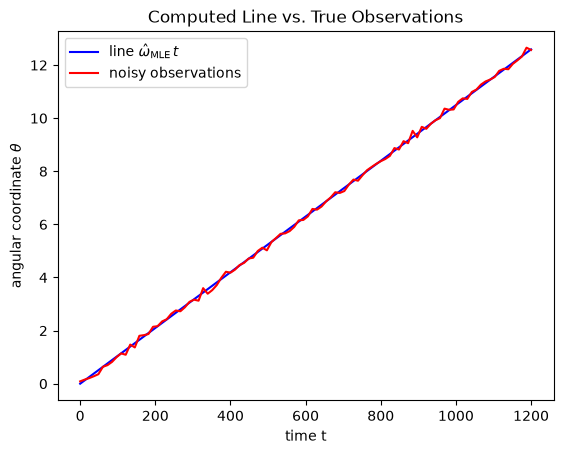

In [5]:
plt.plot(time, w_mle * time, color='blue', label=r'line $\hat{\omega}_{\mathrm{MLE}}\,t$') # use r-format to type latex in labels
plt.plot(time, theta, color='red', label='noisy observations')
plt.legend()
plt.title('Computed Line vs. True Observations')
plt.xlabel('time t')
plt.ylabel(r'angular coordinate $\theta$')
plt.show()

(e) Estimate the noise variance $\sigma^2$ by $\sigma^2 = \frac{1}{N-1}\sum_{i=1}^{N}\left(\theta_i - \hat{\omega}_{\mathrm{MLE}}\, t_i\right)^2$. Be mindful that this assumes i.i.d. Gaussian measurement noise (which I am using). In practical applications, however, outliers, correlated noise, or model mis-specification can bias this estimate.

In [6]:
result = 0
for theta_i, t_i in zip(theta, time):

    result += pow((theta_i - (w_mle*t_i)), 2)

sigma_squared = (1/(len(time)-1))*result 

print(f'Estimated noise variance is: {sigma_squared}')


Estimated noise variance is: 0.007588712373669951


### Bayesian posterior (full dataset)

(a) Select reasonable values for the prior's parameters $\mu_0$ and $\tau_0^2$. Make sure your settings give a very wide prior. Use your best judgement here and justify your choice.

When reading this problem, I began thinking of the example done in class with coin flips. We had three people who had different priors: a) someone who had no idea, b) someone who thought the casino was rigging the coin to have more tails, and c) someone who thought the casino was using a fair 50/50 coin.

$\omega$ is the orbital angular frequency in rad/s for a satellite orbiting around Earth. I don't know that much about satellites, so I googled their angular frequency. Turns out they take about a day to orbit earth and their angular frequency is $\approx 7.29 \times 10^{-5} rad/s$. So pretty small. 
- Therefore, for my $\mu_0$ I will set it to 0, since I do not know the direction of the satellite, but am pretty confident it is going at slow rad/s. 

For the variance, I am thinking back to the "no idea" guy from our casino coin flip example. He had a 100% flat Gaussian, which is infinite variance. While, I don't want to be that quite "no idea", I do want to pick a higher variance. In this case, I will choose a variance of 1.
- This gives a wide-breadth of values that the angular speed can take. This is a very wide prior because it gives high probability to angular speeds that just aren't possible. Since the variance is 1, the standard deviation is also 1, which is hundreds of times larger than any plausable $\omega$.
- Therefore, my chosen $\tau_0^2$ is 1.

(b) Numerically compute the Bayesian posterior mean and variance. Print itse value.

In [7]:
# compute the variance:

prior = 1 # since 1/1=1
precision = 1/sigma_squared

t_sum = 0
for t_i in time:
    t_sum += (pow(t_i, 2)) # base = t_i, exp = 2

variance_N = prior + precision*(t_sum)

variance_N = pow(variance_N, -1)

print(f'Numerically computed Bayesian posterior variance: {variance_N}')

Numerically computed Bayesian posterior variance: 1.5730371123851458e-10


In [8]:
# compute the mean:

theta_sum = 0
for t_i, theta_i in zip(time, theta):

    theta_sum += (t_i * theta_i)

prior = 0 # since my prior mean is 0

mean_N = variance_N * (prior + (precision*theta_sum))

print(f'Numerically computed Bayesian posterior mean: {mean_N}')

Numerically computed Bayesian posterior mean: 0.010493397927075532


(c) Compare the Bayesian posterior mean to the MLE estimate

In [9]:
# compare the computed posterior mean to w_mle

print(f'Numerically computed Bayesian posterior mean: {mean_N}')
print(f'Numerically computed w_MLE: {w_mle}')

Numerically computed Bayesian posterior mean: 0.010493397927075532
Numerically computed w_MLE: 0.010493397928726183


In [10]:
# these values are very, very similar! lets check the absolute value

print(f'Absolute value between w_MLE and Bayesian posterior mean: {abs(w_mle-mean_N)}')

Absolute value between w_MLE and Bayesian posterior mean: 1.6506501027135911e-12


This shows how my prior being very off from the true values (especially the variance) collapses in the face of the true data measurements. It also solidifes the connection between MLE and Bayesian posterior estimates.

### Bayesian filtering

(a) Write code to update the posterior one observation at a time. That is, after each new observation $\theta_k$, compute the (i) posterior mean $\mu_k$ and variance $\tau_k^2$. A simple approach is to maintain variables like $S_{tt}^{(k)} = \sum_{i=1}^{k} t_i^2$ and $S_{t\theta}^{(k)} = \sum_{i=1}^{k} t_i \theta_i$, and update $(\mu_k, \tau_k^2)$ from those. (Note: in the case of conjugate priors – which we have here – the benefits of sequential updating are reduced because computing the summations defining $\mu_k$ and $\tau_k^2$ from scratch is already fast.)


In [11]:

S_tt = 0
S_ttheta = 0

prior_var = 1
prior_mean = 0

uk_list = []
tk_list = []

for k, theta_k in enumerate(theta):

    S_tt += pow(time[k], 2)
    S_ttheta += (time[k] * theta[k])

    var_k = prior_var + precision*S_tt 
    var_k = pow(var_k, -1)
    tk_list.append(var_k)

    mean_k = var_k * (prior_mean + precision*S_ttheta)
    uk_list.append(mean_k)

    # only print first 10 and last 10 to not take up space on PDF documents
    if(k<= 9 or k>=90):
        if(k==0):
            print('First 10: ')
            
        print(f'k = {k+1} - posterior mean = {mean_k} - posterior variance = {var_k}')

        if(k==9):
            print('\nFinal 10:')


First 10: 
k = 1 - posterior mean = 0.0 - posterior variance = 1.0
k = 2 - posterior mean = 0.012732988758418546 - posterior variance = 5.164800593899463e-05
k = 3 - posterior mean = 0.009521106130594708 - posterior variance = 1.0330028008077253e-05
k = 4 - posterior mean = 0.008368057245931926 - posterior variance = 3.689320216958344e-06
k = 5 - posterior mean = 0.007837827576867008 - posterior variance = 1.7216861555680491e-06
k = 6 - posterior mean = 0.009059087778719029 - posterior variance = 9.391022743277468e-07
k = 7 - posterior mean = 0.009276388565551155 - posterior variance = 5.675894975484752e-07
k = 8 - posterior mean = 0.009416841049012253 - posterior variance = 3.689332466974316e-07
k = 9 - posterior mean = 0.009699204619134398 - posterior variance = 2.531895123327562e-07
k = 10 - posterior mean = 0.009915993252754727 - posterior variance = 1.812304008162065e-07

Final 10:
k = 91 - posterior mean = 0.010491261741661189 - posterior variance = 2.090570237892586e-10
k = 92 -

(b) Plot $\mu_k$ vs $k$ with a 95% credible interval band $\mu_k \pm 1.96\tau_k$. Please observe how quickly the uncertainty shrinks as $k$ grows. (Note: you may need to fiddle with the y axis limits to more clearly show how the variance is changing)

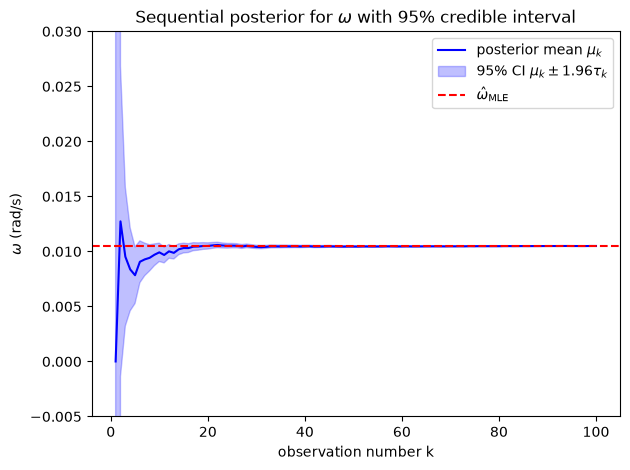

In [12]:
k_vals = list(range(1, len(uk_list) + 1))
mu_k = np.array(uk_list)
tau_k = np.sqrt(np.array(tk_list)) # tk_list is variances, equation needs std. dev

# bc of +- 1.96t_k written in problem question
lower = mu_k - 1.96*tau_k
upper = mu_k + 1.96*tau_k

plt.plot(k_vals, mu_k, color='blue', label=r'posterior mean $\mu_k$')
plt.fill_between(k_vals, lower, upper, color='blue', alpha=0.25, label=r'95% CI $\mu_k \pm 1.96\tau_k$') # fill space between lower and upper bounds
plt.axhline(w_mle, color='red', linestyle='--', label=r'$\hat{\omega}_{\mathrm{MLE}}$')
plt.ylim(-0.005, 0.03) # manually tuned y limits
plt.xlabel('observation number k')
plt.ylabel(r'$\omega$ (rad/s)')
plt.legend()

plt.title(r'Sequential posterior for $\omega$ with 95% credible interval')
plt.tight_layout()
plt.show()


Can clearly see the uncertainty shrinking as k grows. However, the prior of mean = 0 definitely throws off the scale a little bit. So, I'm going to zoom in on where it becomes stable in the next plot, lets say k >= 15.

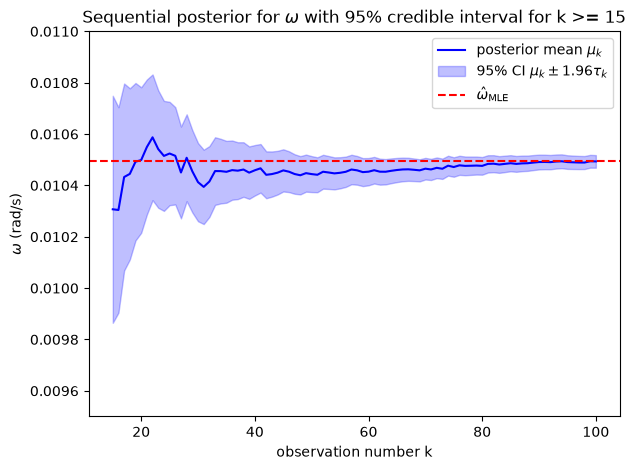

In [13]:
import numpy as np

# convert everything to numpy arrays
k_vals = np.asarray(k_vals)
mu_k   = np.asarray(mu_k)
lower  = np.asarray(lower)
upper  = np.asarray(upper)

zoom = k_vals >= 15

plt.plot(k_vals[zoom], mu_k[zoom], color='blue', label=r'posterior mean $\mu_k$')
plt.fill_between(k_vals[zoom], lower[zoom], upper[zoom], color='blue', alpha=0.25,
                 label=r'95% CI $\mu_k \pm 1.96\tau_k$')
plt.axhline(w_mle, color='red', linestyle='--', label=r'$\hat{\omega}_{\mathrm{MLE}}$')
plt.ylim(0.0095, 0.0110) # use much tighter y-limits
plt.xlabel('observation number k')
plt.ylabel(r'$\omega$ (rad/s)')
plt.legend()
plt.title(r'Sequential posterior for $\omega$ with 95% credible interval for k >= 15')
plt.tight_layout()
plt.show()

Here it can be observed that the uncertainity is shrinking even for large k-values. For example, the difference in uncertainity between k = 60 and k = 100 is significant. This shows how important a large dataset is for Bayesian posterior mean/variance estimation.

### Information gain over time

The entropy of a 1D Gaussian is
$$
H\left(\mathcal{N}(\mu, \tau^2)\right) = \frac{1}{2} + \frac{1}{2}\ln\left(2\pi\tau^2\right)
$$


(a) Set the prior's parameters to $\mu_0 = 0$ and $\tau_0^2 = 1$. Numerically compute the posterior's entropy $H_k$ after each update.

In [14]:
# only parameter that changes with new observations is the variance
import math

S_tt = 0
prior = 1
entropy_k_list = []

for k, time_k in enumerate(time):

    S_tt += pow(time_k, 2)
    t_k = prior + precision*S_tt 
    t_k = pow(t_k, -1)

    entropy_k = 0.5 + 0.5*np.log(2*math.pi*t_k)
    entropy_k_list.append(entropy_k)

    # only print first 10 and last 10 to conserve space on the PDF
    if(k<= 9 or k>=90):
        if(k==0):
            print('First 10: ')
            
        print(f'k = {k+1} - entropy = {entropy_k} - t_k = {t_k}')

        if(k==9):
            print('\nFinal 10:')
    

First 10: 
k = 1 - entropy = 1.4189385332046727 - t_k = 1.0
k = 2 - entropy = -3.516590951958812 - t_k = 5.164800593899463e-05
k = 3 - entropy = -4.321289248546672 - t_k = 1.0330028008077253e-05
k = 4 - entropy = -4.836095636760081 - t_k = 3.689320216958344e-06
k = 5 - entropy = -5.217164678963837 - t_k = 1.7216861555680491e-06
k = 6 - entropy = -5.520232189456533 - t_k = 9.391022743277468e-07
k = 7 - entropy = -5.7719951643421945 - t_k = 5.675894975484752e-07
k = 8 - entropy = -5.98738652306025 - t_k = 3.689332466974316e-07
k = 9 - entropy = -6.175625250805821 - t_k = 2.531895123327562e-07
k = 10 - entropy = -6.342809808038474 - t_k = 1.812304008162065e-07

Final 10:
k = 91 - entropy = -9.725268496835913 - t_k = 2.090570237892586e-10
k = 92 - entropy = -9.741752510979707 - t_k = 2.022771987140717e-10
k = 93 - entropy = -9.758057340413117 - t_k = 1.957873984427374e-10
k = 94 - entropy = -9.774186838908623 - t_k = 1.8957227907134492e-10
k = 95 - entropy = -9.790144737231815 - t_k = 1.83

(b) Plot entropy vs. observation number

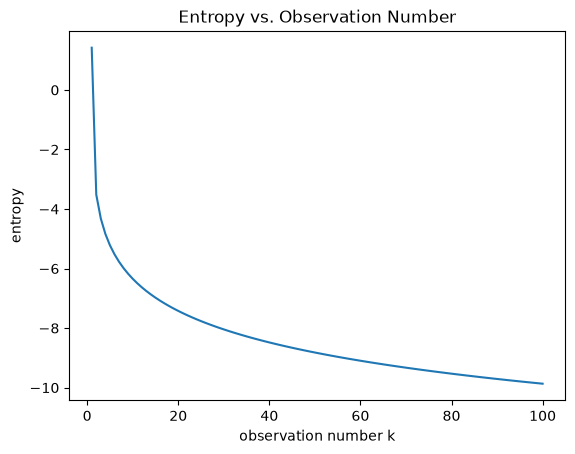

In [15]:
plt.plot(k_vals, entropy_k_list)
plt.ylabel('entropy')
plt.xlabel('observation number k')
plt.title('Entropy vs. Observation Number')
plt.show()

(c) Plot entropy change ($\Delta H_k = H_k - H_{k-1}$) vs. observation number

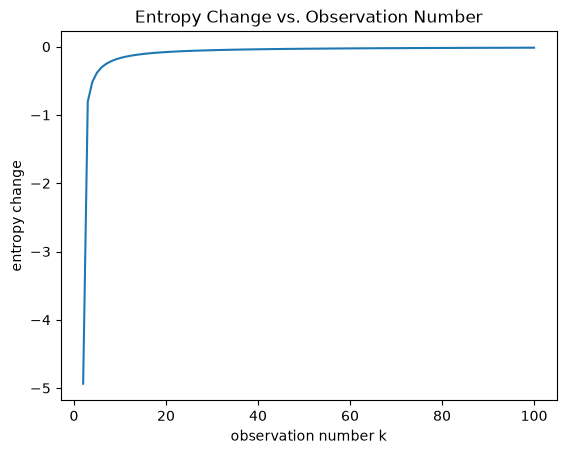

In [16]:

entropy_change = [e - entropy_k_list[k] for k, e in enumerate(entropy_k_list[1:])]

plt.plot(k_vals[1:], entropy_change)
plt.ylabel('entropy change')
plt.xlabel('observation number k')
plt.title('Entropy Change vs. Observation Number')
plt.show()

(d) Why does earlier data reduce entropy more steeply?

To answer this question, I need to look at the entropy formula itself. 
- It only depends on the posterior variance $\tau_k^2$, and the variance changes as new observations $t_k$ come in.
- Each observation adds to the posterior precision: $\frac{1}{\tau_k^2} = \frac{1}{\tau_0^2} + \frac{1}{\sigma^2}\sum_{i=1}^{k} t_i^2$. Since the precision keeps growing, its reciprocal $\tau_k^2$ continues to get smaller and smaller.
- I investigated $\tau_k^2$ by printing it up above, and found it continues to decrease in size, but at a lower and lower rate. For example, when k = 11, $\tau_k^2$ is 1.3415757575055057e-07, and when k goes to 12 the new value is 1.0207641960667052e-07. This is a change of roughly -3.21e-08. Compare this to when k = 99 the value is 1.6214357472450478e-10 and when k = 100 the value is 1.5730371123851458e-10. This is a mere change of roughly -4.84e-12.
- All other values in the entropy formula (H) are constant, so it only depends on $\tau_k^2$. Since $\tau_k^2$ is decreasing at a slower and slower rate, the entropy is also decreasing at a slower and slower rate. Therefore, the entropy change is not as severe for later data.

A second point is more conceptual. The datapoints are your evidence. Let's say you observe something 5 times. This is a rather small sample size, so your opinion can be shifted more easily with new datapoints. But once you have seen 99 points, a single point won't change your opinion right away. It would take much, much more evidence to significantly change your current opinion/result. The calculated $\tau_k^2$ value, and thus entropy, can be thought of in a similar manner.

## Bayesian Estimation of a newly discovered star's mass

A new star was discovered to have an orbiting planet at a distance $r = 1.56479 \times 10^{11}$ meters from its sun! The planet is in a circular orbit in the x-y plane and obeys Kepler's law:

$$
\omega^2 = \frac{GM}{r^3}
$$

Angular coordinates are measured and have the same setup as above (but $\sigma^2$ may take on a different value). An observation was recorded about once per month. The dataset is named SolarData.csv.

Use the dataset to infer a star's mass from noisy angle measurements. **You can use any method you want.** But if you directly use the previous setup (Bayesian Posterior with the full dataset) you can (i) compute the posterior and (ii) map this posterior to mass using Kepler's law for a circular orbit at radius $r$ by sampling $\omega \sim \mathcal{N}(\mu_N, \tau_N^2)$ and pushing those samples through $M(\omega)$.

What's the value of the star's mass? What's your value's error bar?

In [17]:
df_solar = pd.read_csv('SolarData-Hw3.csv')
df_solar.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    12 non-null     float64
 1   theta   12 non-null     float64
dtypes: float64(2)
memory usage: 324.0 bytes


In [18]:
# estimate noise variance first using w_MLE

# know that our w_MLE is one summation divided by another

time = df_solar['time']
theta = df_solar['theta']
numerator_sum = 0

for t_i, theta_i in zip(time, theta):

    numerator_sum += (t_i * theta_i)

denom_sum = 0
for t_i in time:

    denom_sum += (pow(t_i, 2)) # base = t_i, exp = 2

w_mle_solar = numerator_sum/denom_sum
print(f'Numerically computed solar w_MLE: {w_mle_solar}')

Numerically computed solar w_MLE: 2.0033052543162165e-07


In [19]:
result = 0
for theta_i, t_i in zip(theta, time):

    result += pow((theta_i - (w_mle_solar*t_i)), 2)

sigma_squared = (1/(len(time)-1))*result

precision = 1/sigma_squared

print(f'Estimated noise variance is: {sigma_squared}')

Estimated noise variance is: 0.3695969506635018


In [20]:
import scipy.constants as const

precision = 1/sigma_squared

S_tt = 0
S_ttheta = 0

prior_var = 1
prior_mean = 0

uk_list = []
tk_list = []

radius = 1.56479 * pow(10, 11)
radius_3 = pow(radius, 3)

for k, theta_k in enumerate(theta):

    S_tt += pow(time[k], 2)
    S_ttheta += (time[k] * theta[k])

    var_k = prior_var + precision*S_tt 
    var_k = pow(var_k, -1)
    tk_list.append(var_k)

    mean_k = var_k * (prior_mean + precision*S_ttheta)
    uk_list.append(mean_k)

    solar_mass = (pow(mean_k, 2))*(radius_3) / const.G # only different step, compute solar mass using Kepler's law

    print(f'{k} observation ==== Angular posterior: {mean_k} ==== Computed star\'s mass: {solar_mass}\n')

print(f'Angular posterior: {mean_k} ==== Variance posterior: {var_k}\n')
print(f'Final solar mass with all data is: {solar_mass} kilograms')


0 observation ==== Angular posterior: 0.0 ==== Computed star's mass: 0.0

1 observation ==== Angular posterior: 4.765217610624936e-07 ==== Computed star's mass: 1.3035507345319243e+31

2 observation ==== Angular posterior: 3.010240549478582e-07 ==== Computed star's mass: 5.201934334688613e+30

3 observation ==== Angular posterior: 1.9855591563592013e-07 ==== Computed star's mass: 2.2632270427805107e+30

4 observation ==== Angular posterior: 2.238687547183298e-07 ==== Computed star's mass: 2.8770633811281873e+30

5 observation ==== Angular posterior: 1.758383016117606e-07 ==== Computed star's mass: 1.774963485195643e+30

6 observation ==== Angular posterior: 1.9597108825204908e-07 ==== Computed star's mass: 2.2046846131179826e+30

7 observation ==== Angular posterior: 1.8923715422091577e-07 ==== Computed star's mass: 2.0557735749898338e+30

8 observation ==== Angular posterior: 1.9925011945324354e-07 ==== Computed star's mass: 2.279080384735109e+30

9 observation ==== Angular posterior:

In [21]:
np.random.seed(42) # set seed because sampling randomly from a Gaussian
omega_samples = np.random.normal(mean_k, np.sqrt(var_k), size=100_000)
M_samples = omega_samples**2 * radius_3 / const.G

M_mean = np.mean(M_samples)
M_std = np.std(M_samples)
M_lo, M_hi = np.percentile(M_samples, [2.5, 97.5])

print(f'M = {M_mean:.4e} +/- {M_std:.2e} kg')
print(f'95% credible interval: [{M_lo:.4e}, {M_hi:.4e}] kg')

M = 2.3092e+30 +/- 2.17e+29 kg
95% credible interval: [1.8979e+30, 2.7487e+30] kg


## Challenge (+ 10 points)

The group with the closest value to the true $M$.

First, just take a look at the solar $\hat{\omega}_{MLE}$ line against the true observations.

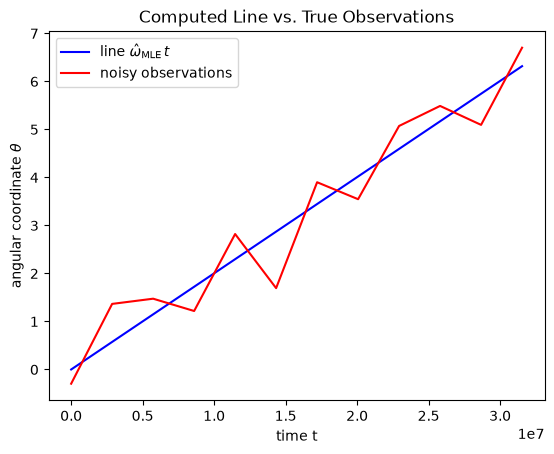

In [22]:
# very jumpy graph, lets take a look with the w_mle_solar

plt.plot(time, w_mle_solar * time, color='blue', label=r'line $\hat{\omega}_{\mathrm{MLE}}\,t$') # use r-format to type latex in labels
plt.plot(time, theta, color='red', label='noisy observations')
plt.legend()
plt.title('Computed Line vs. True Observations')
plt.xlabel('time t')
plt.ylabel(r'angular coordinate $\theta$')
plt.show()

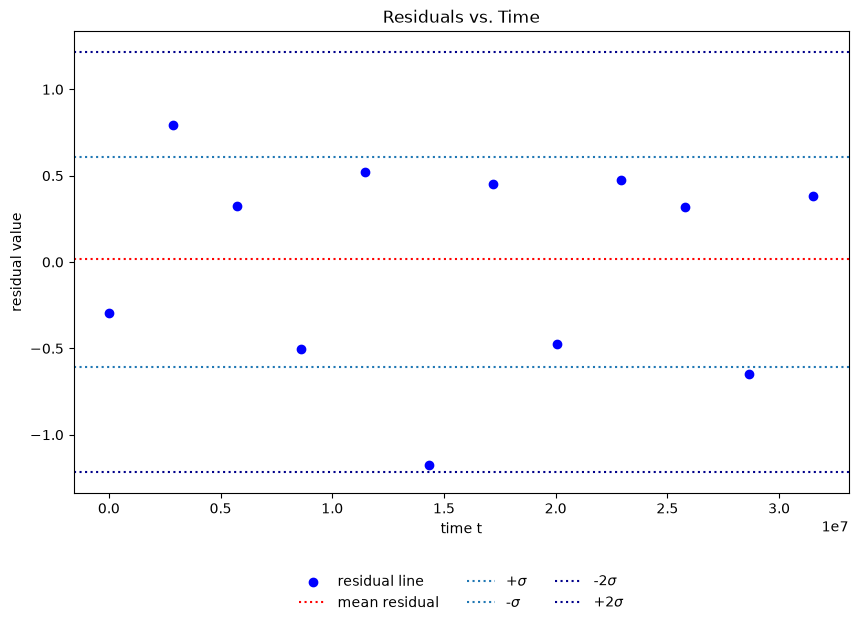

Mean residual: 0.01484766477086604 === Std. dev of residuals: 0.5818734842091781


In [23]:
# try to now plot the residuals from my observed values

residuals = [theta_i - mean_k*t_i for theta_i, t_i in zip(theta, time)]
mean_residual = np.mean(residuals)

sigma = math.sqrt(sigma_squared)

plt.figure(figsize=(10,6))
plt.scatter(time, residuals, color='blue', label='residual line') # use r-format to type latex in labels
plt.axhline(y=mean_residual, linestyle=':', color='red', label='mean residual')
plt.axhline(y=sigma, linestyle=':', label=r'+$\sigma$')
plt.axhline(y=-sigma, linestyle=':', label=r'-$\sigma$')
plt.axhline(y=-2*sigma, linestyle=':', label=r'-2$\sigma$', color='#00008B')
plt.axhline(y=2*sigma, linestyle=':', label=r'+2$\sigma$', color='#00008B')
plt.title('Residuals vs. Time')
plt.xlabel('time t')
plt.ylabel(r'residual value')
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.show()

print(f'Mean residual: {mean_residual} === Std. dev of residuals: {np.std(residuals)}')

Almost all points fall within +- one standard deviation. Three points fall outside of that range, with the point at ~t = 1.5e7 being the largest outlier. Another thing I noticed is that at time t, the mean will also evaluate to zero. Therefore, I run a new test without t=0 and the largest outlier point.

In [24]:
# estimate noise variance first using w_MLE

# know that our w_MLE is one summation divided by another

time = df_solar['time']
time = time.drop(time.index[[0, 5]]) # drop t=0 and noisy point
time = time.reset_index(drop=True)

theta = df_solar['theta']
theta = theta.drop(theta.index[[0, 5]])
theta = theta.reset_index(drop=True)

numerator_sum = 0

for t_i, theta_i in zip(time, theta):

    numerator_sum += (t_i * theta_i)

denom_sum = 0
for t_i in time:

    denom_sum += (pow(t_i, 2)) # base = t_i, exp = 2

w_mle_solar = numerator_sum/denom_sum
print(f'Numerically computed solar w_MLE: {w_mle_solar}')

Numerically computed solar w_MLE: 2.0459917239356262e-07


In [25]:
result = 0
for theta_i, t_i in zip(theta, time):

    result += pow((theta_i - (w_mle_solar*t_i)), 2)

sigma_squared = (1/(len(time)-1))*result

precision = 1/sigma_squared

print(f'Estimated noise variance is: {sigma_squared}')

Estimated noise variance is: 0.2799908118724405


In [26]:
import scipy.constants as const

precision = 1/sigma_squared

S_tt = 0
S_ttheta = 0

prior_var = 1
prior_mean = 0

uk_list = []
tk_list = []

radius = 1.56479 * pow(10, 11)
radius_3 = pow(radius, 3)

for k, theta_k in enumerate(theta):

    S_tt += pow(time[k], 2)
    S_ttheta += (time[k] * theta[k])

    var_k = prior_var + precision*S_tt 
    var_k = pow(var_k, -1)
    tk_list.append(var_k)

    mean_k = var_k * (prior_mean + precision*S_ttheta)
    uk_list.append(mean_k)

    solar_mass = (pow(mean_k, 2))*(radius_3) / const.G # only different step, compute solar mass using Kepler's law

    print(f'{k} observation ==== Angular posterior: {mean_k} ==== Computed star\'s mass: {solar_mass}\n')

print(f'Angular posterior: {mean_k} ==== Variance posterior: {var_k}\n')
print(f'Final solar mass with all data is: {solar_mass} kilograms')


0 observation ==== Angular posterior: 4.765217610624988e-07 ==== Computed star's mass: 1.3035507345319531e+31

1 observation ==== Angular posterior: 3.0102405494785885e-07 ==== Computed star's mass: 5.201934334688636e+30

2 observation ==== Angular posterior: 1.9855591563592029e-07 ==== Computed star's mass: 2.2632270427805147e+30

3 observation ==== Angular posterior: 2.238687547183298e-07 ==== Computed star's mass: 2.8770633811281873e+30

4 observation ==== Angular posterior: 2.254291679369626e-07 ==== Computed star's mass: 2.917310657293537e+30

5 observation ==== Angular posterior: 2.0467963168548935e-07 ==== Computed star's mass: 2.4049813675463546e+30

6 observation ==== Angular posterior: 2.1056972302438413e-07 ==== Computed star's mass: 2.5453898864489645e+30

7 observation ==== Angular posterior: 2.1124646232419238e-07 ==== Computed star's mass: 2.5617771749654094e+30

8 observation ==== Angular posterior: 2.0193303553440297e-07 ==== Computed star's mass: 2.3408695375207106e+3

In [27]:
np.random.seed(42) # set seed because sampling randomly from a Gaussian
omega_samples = np.random.normal(mean_k, np.sqrt(var_k), size=100_000)
M_samples = omega_samples**2 * radius_3 / const.G

M_mean = np.mean(M_samples)
M_std = np.std(M_samples)
M_lo, M_hi = np.percentile(M_samples, [2.5, 97.5])

print(f'M = {M_mean:.4e} +/- {M_std:.2e} kg')
print(f'95% credible interval: [{M_lo:.4e}, {M_hi:.4e}] kg')

M = 2.4074e+30 +/- 1.98e+29 kg
95% credible interval: [2.0307e+30, 2.8064e+30] kg


I now have a slightly higher mass and a lower standard deviation (since I dropped the noisest data point). Only really one more thing to try, which is refining my prior estimates for mean and variance.

- For the mean, I am setting the new prior to $1.86 \times 10^{-7}$. Instead of using a wide prior, I am assuming that the new star has a mass equal to the sun. The chosen prior is calculated from the Kepler's law formula, plugging in our given radius. 
- For the variance, I am going to choose $7 \times 10^{-17}$ using the computed variance from before.

In [28]:
import scipy.constants as const

precision = 1/sigma_squared

S_tt = 0
S_ttheta = 0

prior_var = 7 * pow(10, -17)
prior_mean = 1.86 * pow(10, -7)

uk_list = []
tk_list = []

radius = 1.56479 * pow(10, 11)
radius_3 = pow(radius, 3)

for k, theta_k in enumerate(theta):

    S_tt += pow(time[k], 2)
    S_ttheta += (time[k] * theta[k])

    var_k = prior_var + precision*S_tt 
    var_k = pow(var_k, -1)
    tk_list.append(var_k)

    mean_k = var_k * (prior_mean + precision*S_ttheta)
    uk_list.append(mean_k)

    solar_mass = (pow(mean_k, 2))*(radius_3) / const.G # only different step, compute solar mass using Kepler's law

    print(f'{k} observation ==== Angular posterior: {mean_k} ==== Computed star\'s mass: {solar_mass}\n')

print(f'Angular posterior: {mean_k} ==== Variance posterior: {var_k}\n')
print(f'Final solar mass with all data is: {solar_mass} kilograms')


0 observation ==== Angular posterior: 4.765217610625214e-07 ==== Computed star's mass: 1.3035507345320768e+31

1 observation ==== Angular posterior: 3.010240549478622e-07 ==== Computed star's mass: 5.201934334688751e+30

2 observation ==== Angular posterior: 1.985559156359212e-07 ==== Computed star's mass: 2.2632270427805352e+30

3 observation ==== Angular posterior: 2.2386875471833027e-07 ==== Computed star's mass: 2.8770633811281997e+30

4 observation ==== Angular posterior: 2.254291679369628e-07 ==== Computed star's mass: 2.917310657293543e+30

5 observation ==== Angular posterior: 2.0467963168548949e-07 ==== Computed star's mass: 2.4049813675463582e+30

6 observation ==== Angular posterior: 2.105697230243842e-07 ==== Computed star's mass: 2.545389886448967e+30

7 observation ==== Angular posterior: 2.112464623241924e-07 ==== Computed star's mass: 2.5617771749654105e+30

8 observation ==== Angular posterior: 2.0193303553440302e-07 ==== Computed star's mass: 2.3408695375207117e+30

9

This was kind of expected. The final solar mass didn't change at all. This is because the data (albeit a small dataset) is still useful enough information. I found this quote from Google, "Different prior leads to different posterior. But this difference
tends to be negligible when the data is very informative."

Thefore, my final submitted solar mass for the bonus question is:

M = 2.4074e+30 +/- 1.98e+29 kg

95% credible interval: [2.0307e+30, 2.8064e+30] kg

, obtained from removing the non-informative point at t=0 and the outlier point at -1.9 standard deviations.